In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from sklearn.feature_extraction.text import CountVectorizer


In [8]:
df = pd.read_csv("spam.csv")
df.head()

,label,sms
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df['label'] = df['label'].replace({"ham": 1, "spam":0})
df

,label,sms
0,1,"Go until jurong point, crazy.. Available only ..."
1,1,Ok lar... Joking wif u oni...
2,0,Free entry in 2 a wkly comp to win FA Cup fina...
3,1,U dun say so early hor... U c already then say...
4,1,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,0,This is the 2nd time we have tried 2 contact u...
5568,1,Will Ì_ b going to esplanade fr home?
5569,1,"Pity, * was in mood for that. So...any other s..."
5570,1,The guy did some bitching but I acted like i'd...


In [11]:
df.shape

(5572, 2)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.shape

(5169, 2)

In [14]:
df.isnull().sum()

label    0
sms      0
dtype: int64

In [16]:
cv = CountVectorizer(max_features=500, min_df=10)

In [66]:
y = df['label']
y

0       1
1       1
2       0
3       1
4       1
       ..
5567    0
5568    1
5569    1
5570    1
5571    1
Name: label, Length: 5169, dtype: object

In [101]:
y.value_counts()

label
1    4516
0     653
Name: count, dtype: int64

In [68]:
x = df["sms"]
x

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: sms, Length: 5169, dtype: str

In [69]:
x = cv.fit_transform(x)

In [70]:
print(x)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 46830 stored elements and shape (5169, 500)>
  Coords	Values
  (0, 159)	1
  (0, 433)	1
  (0, 305)	1
  (0, 207)	1
  (0, 167)	1
  (0, 480)	1
  (0, 403)	1
  (0, 166)	1
  (0, 451)	1
  (1, 299)	1
  (1, 221)	1
  (1, 468)	1
  (2, 207)	1
  (2, 148)	1
  (2, 417)	3
  (2, 470)	1
  (2, 254)	1
  (2, 392)	1
  (2, 342)	1
  (2, 431)	1
  (2, 336)	1
  (2, 37)	1
  (3, 124)	1
  (3, 352)	2
  (3, 374)	1
  :	:
  (5166, 34)	1
  (5166, 309)	1
  (5167, 207)	1
  (5167, 148)	1
  (5167, 417)	1
  (5167, 186)	1
  (5167, 210)	1
  (5167, 456)	1
  (5167, 32)	1
  (5167, 233)	1
  (5167, 375)	1
  (5167, 146)	1
  (5167, 400)	1
  (5167, 52)	1
  (5167, 284)	1
  (5167, 109)	1
  (5167, 437)	1
  (5167, 70)	1
  (5167, 377)	1
  (5167, 129)	1
  (5167, 172)	1
  (5168, 417)	1
  (5168, 279)	1
  (5168, 211)	2
  (5168, 426)	1


In [95]:
print(x.toarray())

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [22]:
from sklearn.feature_extraction.text import CountVectorizer
corpus = [
    "AI lab teaches deep learning",
    "Deep learning improves AI systems",
    "AI systems use models"
]
vectorizer = CountVectorizer()
x = vectorizer.fit_transform(corpus)
print(x) # sparse represnetation
print(x.toarray())
print(vectorizer.get_feature_names_out())

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 14 stored elements and shape (3, 9)>
  Coords	Values
  (0, 0)	1
  (0, 3)	1
  (0, 7)	1
  (0, 1)	1
  (0, 4)	1
  (1, 0)	1
  (1, 1)	1
  (1, 4)	1
  (1, 2)	1
  (1, 6)	1
  (2, 0)	1
  (2, 6)	1
  (2, 8)	1
  (2, 5)	1
[[1 1 0 1 1 0 0 1 0]
 [1 1 1 0 1 0 1 0 0]
 [1 0 0 0 0 1 1 0 1]]
['ai' 'deep' 'improves' 'lab' 'learning' 'models' 'systems' 'teaches'
 'use']


In [71]:
# spliting data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [72]:
x_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 37201 stored elements and shape (4135, 500)>

In [73]:
y_train

3794    1
4290    1
2603    1
3452    1
3132    1
       ..
5307    1
3455    1
1708    1
2730    1
2871    1
Name: label, Length: 4135, dtype: object

In [60]:
x_train.shape

(4135, 500)

In [29]:
x_test.shape

(1034, 500)

In [61]:
y_train.shape

(4135,)

In [62]:
y_test.shape

(1034,)

In [74]:
model = MultinomialNB()

In [85]:
y_train = y_train.astype(int)
y_train
y_test = y_test.astype(int)

In [83]:
y_train
model.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [86]:
model.score(x_test, y_test)

0.9825918762088974

In [87]:
y_pred = model.predict(x_test)

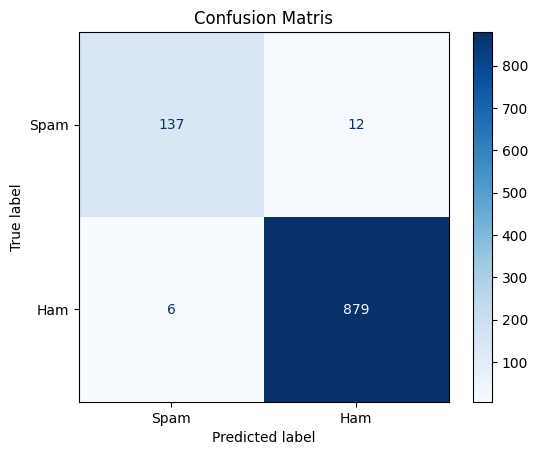

In [97]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Spam', 'Ham'])
disp.plot(cmap='Blues')
plt.title("Confusion Matris")
plt.show()

In [96]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       149
           1       0.99      0.99      0.99       885

    accuracy                           0.98      1034
   macro avg       0.97      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [ ]:
exmple=["money for scheme laptop buy"]
#example=["I will give you scheme on laptop for government buy it"]
#example=["Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."]


In [99]:
example=cv.transform(exmple)

In [100]:
print(example)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (1, 500)>
  Coords	Values
  (0, 71)	1
  (0, 146)	1
  (0, 270)	1


In [92]:
prediction=model.predict(example)

In [93]:
prediction

array([1])